# Data Science Osaka Summer 2026 - Starter

基本的な特徴量を作ってLightGBMで予測します。

In [1]:
# ライブラリのインポート
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error

plt.style.use('ggplot')
SEED = 2026

In [2]:
from pathlib import Path

# Kaggleとローカルでデータの場所を切り替えます
INPUT_DIR = Path('/kaggle/input/competitions/data-science-osaka-summer-2026')
if not (INPUT_DIR / 'train.csv').exists():
    INPUT_DIR = Path('data/competition')
    if not INPUT_DIR.exists():
        INPUT_DIR = Path('../data/competition')

print(INPUT_DIR)

/kaggle/input/competitions/data-science-osaka-summer-2026


In [3]:
# データセットをpandasのDataFrameとして読み込む
df_train = pd.read_csv(INPUT_DIR / 'train.csv')
df_test = pd.read_csv(INPUT_DIR / 'test.csv')
businesses = pd.read_csv(INPUT_DIR / 'businesses.csv')
categories = pd.read_csv(INPUT_DIR / 'business_categories.csv')
interactions = pd.read_csv(
    INPUT_DIR / 'interactions.csv', parse_dates=['interaction_time']
)
df_train = df_train.merge(
    interactions[['user_id', 'business_id', 'interaction_time']],
    on=['user_id', 'business_id'], how='left',
)

df_train.shape, df_test.shape

((2000000, 7), (200000, 5))

In [4]:
# 学習データの先頭部分を見てみる
df_train.head()

,row_id,user_id,business_id,prediction_period,region_group,rating,interaction_time
0,0,384611,24302,2019-Q3,mainland,5,2019-09-24 04:40:40+00:00
1,1,105600,91854,2019-Q1,mainland,5,2019-01-06 22:37:38+00:00
2,2,203944,90601,2018-Q4,mainland,5,2018-10-10 00:25:23+00:00
3,3,348301,67266,2020-Q1,mainland,5,2020-01-17 15:49:50+00:00
4,4,32073,22718,2017-Q3,mainland,4,2017-07-05 17:28:15+00:00


In [5]:
# testにはratingが含まれていません
df_test.head()

,row_id,user_id,business_id,prediction_period,region_group
0,0,189105,32649,2020-Q1,mainland
1,1,301564,70860,2021-Q2,mainland
2,2,87016,12841,2020-Q1,hawaii
3,3,388244,8061,2020-Q2,hawaii
4,4,19253,8202,2021-Q1,mainland


In [6]:
# 追加テーブルも順に見ておきましょう
businesses.head()

,business_id,region_id,city_id,category_count,description,latitude,longitude,price,hours_available,misc_attribute_count
0,45213,0,377,4,NaN,38.836,-121.168,NaN,1,0
1,23609,0,2088,4,NaN,33.683,-117.850,NaN,1,2
2,44256,0,684,1,NaN,32.737,-117.061,NaN,1,2
3,91423,0,3988,5,NaN,34.216,-118.501,NaN,1,1
4,25327,0,1628,1,NaN,34.203,-118.673,NaN,1,2


In [7]:
categories.head()

,business_id,category
0,45213,Spa
1,45213,Massage spa
2,45213,Massage therapist
3,45213,Thai massage therapist
4,23609,Office space rental agency


In [8]:
# 店舗ごとにcategoryはひとつとは限らず複数割り当てられているようですね
# ここではエイヤで最初のカテゴリをひとつ使います
primary_category = categories.drop_duplicates('business_id').rename(
    columns={'category': 'primary_category'}
)
businesses = businesses.merge(primary_category, on='business_id', how='left')
businesses['description_length'] = businesses.description.fillna('').str.len()
businesses['price_level'] = businesses.price.fillna('').astype(str).str.count(r'\$')

In [9]:
# descriptionも数値に変換してみます
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
tfidf = vectorizer.fit_transform(businesses.description.fillna('__MISSING__'))

n_components = 10
svd = TruncatedSVD(n_components=n_components, random_state=SEED)
description_svd = svd.fit_transform(tfidf)
description_columns = [f'description_svd_{i}' for i in range(n_components)]
businesses[description_columns] = description_svd

In [10]:
def make_features(history, target, training=False):
    global_mean = history.rating.mean()
    feature = target.merge(
        businesses, on='business_id', how='left'
    )
    feature['period_year'] = feature.prediction_period.str[:4].astype(int)
    feature['period_quarter'] = feature.prediction_period.str[-1].astype(int)

    # userとbusinessのrating平均・件数を追加します (= Target Encoding!)
    for key, strength in [('user_id', 8), ('business_id', 12)]:
        stats = history.groupby(key).rating.agg(['sum', 'count'])
        total = feature[key].map(stats['sum']).fillna(0)
        count = feature[key].map(stats['count']).fillna(0)
        if training:
            # 学習行自身のratingは平均から引いておきます
            total = total - feature.rating
            count = count - 1
        feature[f'{key}_mean'] = (total + strength * global_mean) / (count + strength)
        feature[f'{key}_count'] = count.fillna(0)
    return feature


numeric_columns = [
    'period_year', 'period_quarter',
    'latitude', 'longitude', 'category_count', 'hours_available',
    'misc_attribute_count', 'description_length', 'price_level',
    'user_id_mean', 'user_id_count', 'business_id_mean', 'business_id_count',
] + description_columns
category_columns = ['region_group', 'region_id', 'city_id', 'primary_category']


def encode(train_feature, target_feature):
    # カテゴリ変数に背番号を振ります
    for column in category_columns:
        values = pd.concat([
            train_feature[column].fillna('__MISSING__'),
            target_feature[column].fillna('__MISSING__'),
        ]).astype('category')
        train_feature[column] = values.iloc[:len(train_feature)].cat.codes.to_numpy()
        target_feature[column] = values.iloc[len(train_feature):].cat.codes.to_numpy()
    use_columns = numeric_columns + category_columns
    return train_feature[use_columns], target_feature[use_columns]

In [11]:
# 時系列の後ろ20%を手元の検定データにします
cutoff = df_train.interaction_time.quantile(0.8)
train_ = df_train[df_train.interaction_time <= cutoff].copy()
val = df_train[df_train.interaction_time > cutoff].copy()

X_train = make_features(train_, train_, training=True)
X_val = make_features(train_, val)
X_train, X_val = encode(X_train, X_val)

model = lgb.LGBMRegressor(
    learning_rate=0.05,
    n_estimators=2000,
    num_leaves=24,
    min_child_samples=50,
    colsample_bytree=0.8,
    subsample=0.8,
    reg_lambda=2,
    random_state=SEED,
    verbosity=-1,
)
model.fit(
    X_train,
    train_.rating,
    eval_set=[(X_val, val.rating)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
    categorical_feature=category_columns,
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.899507
[200]	valid_0's l2: 0.898982
Early stopping, best iteration is:
[167]	valid_0's l2: 0.898961


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, min_child_samples=50,
              n_estimators=2000, num_leaves=24, random_state=2026, reg_lambda=2,
              subsample=0.8, verbosity=-1)

0.948133527536645


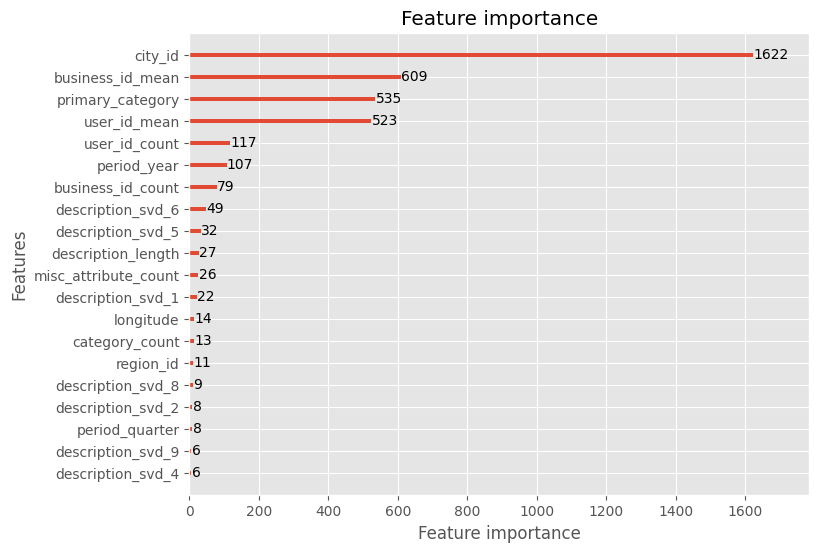

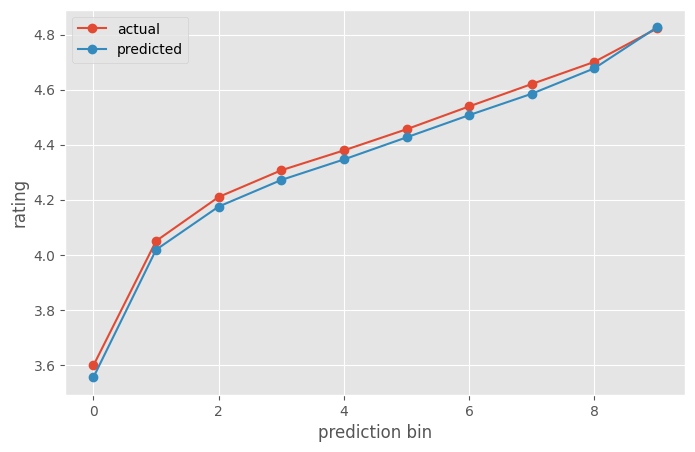

In [12]:
y_pred_val = model.predict(X_val).clip(1, 5)
print(mean_squared_error(val.rating, y_pred_val) ** 0.5)

lgb.plot_importance(model, max_num_features=20, figsize=(8, 6))
plt.show()

# 予測値を10分割して、実際のrating平均を見ます
plot_df = pd.DataFrame({'rating': val.rating, 'prediction': y_pred_val})
plot_df['prediction_bin'] = pd.qcut(
    plot_df.prediction, 10, labels=False, duplicates='drop'
)
calibration = plot_df.groupby('prediction_bin').agg(
    actual=('rating', 'mean'),
    predicted=('prediction', 'mean'),
)

calibration.plot(marker='o', figsize=(8, 5))
plt.xlabel('prediction bin')
plt.ylabel('rating')
plt.show()

In [13]:
# 学習データ全部を使って再学習します
X_train = make_features(df_train, df_train, training=True)
X_test = make_features(df_train, df_test)
X_train, X_test = encode(X_train, X_test)

model = lgb.LGBMRegressor(
    learning_rate=0.05,
    n_estimators=model.best_iteration_,
    num_leaves=24,
    min_child_samples=50,
    colsample_bytree=0.8,
    subsample=0.8,
    reg_lambda=2,
    random_state=SEED,
    verbosity=-1,
)
model.fit(X_train, df_train.rating, categorical_feature=category_columns)
y_pred_test = model.predict(X_test).clip(1, 5)

In [14]:
submission = pd.read_csv(INPUT_DIR / 'sample_submission.csv')
submission['rating'] = y_pred_test
submission.to_csv('submission_starter.csv', index=False)
submission.head()

,row_id,rating
0,0,4.703219
1,1,3.538696
2,2,4.949631
3,3,4.265802
4,4,4.695958


カテゴリを複数使う、集計の粒度やvalidationの切り方を変えるなど色々試してみてください。